# Lab: Model Comparison and Evaluation for Loan Repayment Prediction

### Objective:
In this lab, you will analyze and evaluate the performance of two machine learning models—**Decision Tree** and **Random Forest**—for predicting whether a loan will be fully paid or not. You will compare the models based on various metrics such as accuracy, precision, recall, F1-score, and confusion matrices. This lab will help you understand the importance of model evaluation and the implications of class imbalance on model performance.

### Instructions:
1. **Load and Explore the Data**: Start by loading the loan dataset and performing some basic exploratory data analysis.
2. **Train Decision Tree and Random Forest Models**: Build a Decision Tree and a Random Forest model to predict whether a loan will be fully paid or not.
3. **Evaluate Model Performance**: Use classification metrics and confusion matrices to evaluate the performance of both models.
4. **Compare the Models**: Analyze the results to determine which model performed better and why.
5. **Critical Thinking Questions**: Answer questions to reflect on the model performance and potential improvements.

### Dataset:
You will use a dataset named `loan_data.csv`, which contains information about loans, including whether they were fully paid or not. The target variable is `not.fully.paid`.

The dataset is from the Lending Club (www.lendingclub.com). Lending Club connects people who need money (borrowers) with people who have money (investors). Hopefully, as an investor you would want to invest in people who showed a profile of having a high probability of paying you back. We will try to create a model that will help predict this.


---

## Section 1: Data Exploration

### Step 1.1: Load the Dataset
1. Load the `loan_data.csv` file into a Pandas DataFrame.
2. Display basic information about the dataset using `.info()`, `.head()`, and `.describe()`.`, and `.describe()`.

In [18]:
#Import required libraries
import pandas as pd

#Import visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Display plot within notebook
%matplotlib inline

In [19]:
df=pd.read_csv('data/loan_data.csv', sep=',', header=0)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [21]:
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [22]:
df.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


### Step 1.2: Exploratory Data Analysis (EDA)
- **Create** histograms to visualize the distribution of FICO scores for loans based on the `credit.policy` and `not.fully.paid` variables.
- **Create** a count plot to visualize the purpose of the loans and their repayment status.

See samples below. Don't worry about matching the color or desing.

Text(0.5, 0, 'FICO')

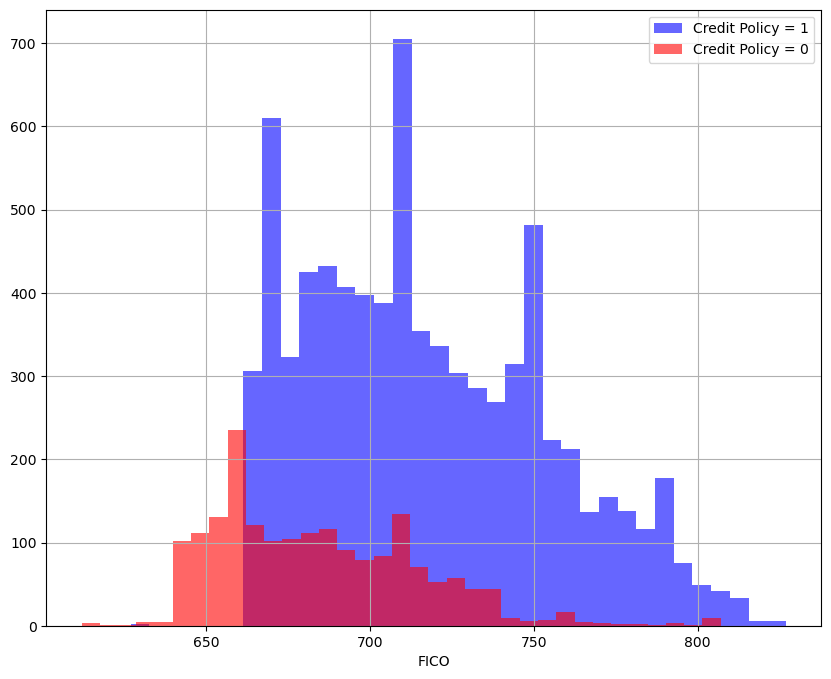

In [28]:
plt.figure(figsize=(10,8))

df[df['credit.policy']==1]['fico'].hist(bins=35, color='blue', alpha=0.6, label='Credit Policy = 1')
df[df['credit.policy']==0]['fico'].hist(bins=35, color='red', alpha=0.6, label='Credit Policy = 0')

plt.legend()

plt.xlabel('FICO')

Text(0.5, 0, 'FICO')

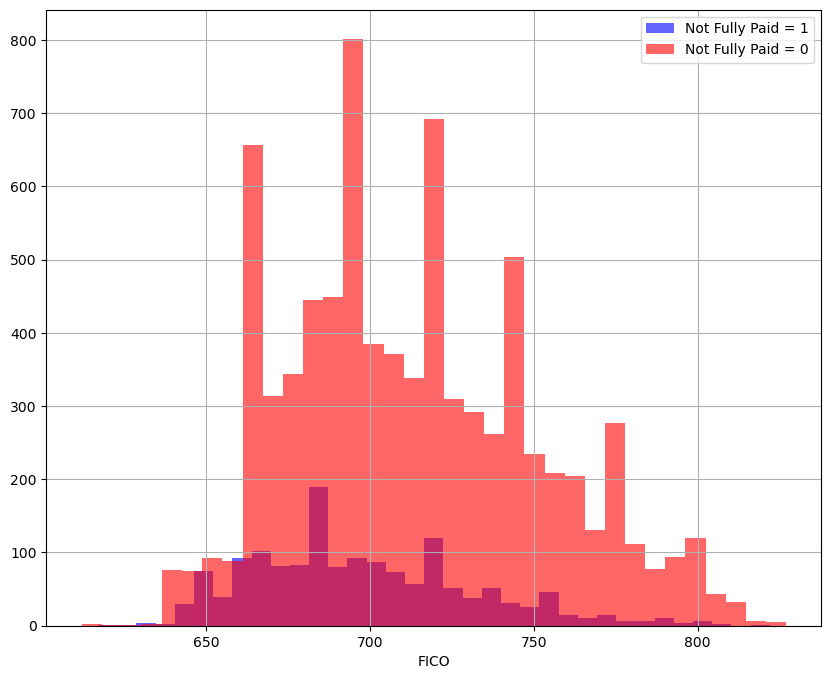

In [29]:
plt.figure(figsize=(10,8))

df[df['not.fully.paid']==1]['fico'].hist(bins=35, color='blue', alpha=0.6, label='Not Fully Paid = 1')
df[df['not.fully.paid']==0]['fico'].hist(bins=35, color='red', alpha=0.6, label='Not Fully Paid = 0')

plt.legend()

plt.xlabel('FICO')

<Axes: xlabel='purpose', ylabel='count'>

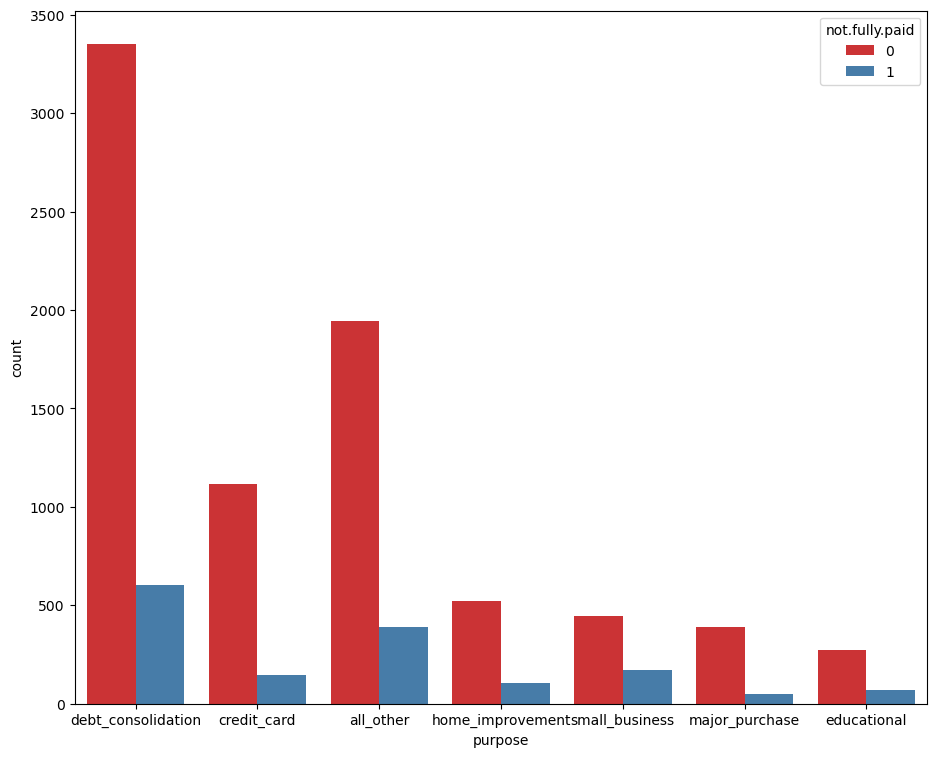

In [30]:
plt.figure(figsize=(11,9))
sns.countplot(x='purpose', hue='not.fully.paid', data=df, palette='Set1')

## Section 2: Model Training and Evaluation
### Step 2.1: Preparing Data for Machine Learning
- **Convert** the `purpose` column to dummy variables using `pd.get_dummies()`.
- **Split** the data into training and test sets using `train_test_split()`.
- use test_size=0.30, random_state=101

In [38]:
df_dummies = pd.get_dummies(df, columns=['purpose'], drop_first=True)


In [39]:
from sklearn.model_selection import train_test_split

X = df_dummies.drop('not.fully.paid', axis=1)
y = df_dummies['not.fully.paid']

X_train, X_test, y_train, y_test, = train_test_split(X, y, test_size=0.3, random_state=101)

### Step 2.2: Train a Decision Tree Model
- **Train** a `DecisionTreeClassifier` on the training data.
- **Evaluate** the model on the test data using a classification report and confusion matrix.

In [40]:
from sklearn.tree import DecisionTreeClassifier

In [41]:
dtree = DecisionTreeClassifier()

In [42]:
dtree.fit(X_train, y_train)

DecisionTreeClassifier()

In [44]:
predict = dtree.predict(X_test)

In [45]:
from sklearn.metrics import classification_report,confusion_matrix

In [46]:
print(classification_report(y_test, predict))

              precision    recall  f1-score   support

           0       0.86      0.82      0.84      2431
           1       0.20      0.24      0.22       443

    accuracy                           0.73      2874
   macro avg       0.53      0.53      0.53      2874
weighted avg       0.76      0.73      0.74      2874



In [59]:
confusion_matrix(y_test, predict)

array([[2003,  428],
       [ 335,  108]], dtype=int64)

### Step 2.3: Train a Random Forest Model
- **Train** a `RandomForestClassifier` on the training data.
- **Evaluate** the model on the test data using a classification report and confusion matrix.

In [48]:
from sklearn.ensemble import RandomForestClassifier

In [50]:
model = RandomForestClassifier(n_estimators=10, random_state=101)

In [51]:
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=101)

In [52]:
rt_predict = model.predict(X_test)

In [60]:
print(classification_report(y_test, rt_predict))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91      2431
           1       0.25      0.04      0.07       443

    accuracy                           0.83      2874
   macro avg       0.55      0.51      0.49      2874
weighted avg       0.76      0.83      0.78      2874



In [54]:
confusion_matrix(y_test, rt_predict)

array([[2374,   57],
       [ 424,   19]], dtype=int64)

## Section 3: Model Comparison and Critical Thinking

### Step 3.1: Compare the Models
- **Compare** the classification reports and confusion matrices of both models.
- **Discuss** which model performs better based on your evaluation.

**Answer the questions below**

**Questions for Model Comparison:**
1. Which model has a higher overall accuracy, and what does this tell you about its performance?
2. Which model is better at identifying loans that are not fully paid (class `1`)?
3. How does class imbalance affect the performance of these models?
4. What steps can you take to improve the performance of these models, especially for class `1`?

1. **Which model has a higher overall accuracy, and what does this tell you about its performance?**

The random forest model has a higher overall accuracy than the decision tree model, 83% compared to 73%.  Higher accuracy suggests that the random forest model is better at correctly classifying instances across both classes in general.

2. **Which model is better at identifying loans that are not fully paid (class `1`)?**

The decision treel model has slightly better precision (0.20 vs. 0.25), meaning it is more accurate when predicting a loan is not fully paid.

3. **How does class imbalance affect the performance of these models?**

Class imbalance leads to a bias toward the majority class.  Both models predict the majority class (class 0) more frequently, leading to high overall accuracy but poor identification of the minority class (class 1).

4. **What steps can you take to improve the performance of these models, especially for (class `1`)?**

Experiment with different models, hyperparamater tuning, or cross-validation.  You can also evaluate using alternative metrics such as precision, recall, and F1-score instead of just accuracy to better understand model performance, especially for class 1.

### Step 3.2: Reflection
- Write a short reflection (2-3 sentences) on what you learned from this lab. What were the main challenges in comparing the models, and how did you address them?

**Reflection:**

In this lab, I learned the importance of evaluating machine learning models using various metrics, particular in the context of class imbalance.  One of the main challenges was interpreting the models' performance metrics, especially when high accuracy masked poor recall for the minority class.  To address this we should focus on precision, recall, and F1-score to better identify loans that are not fully paid.